In [29]:
import numpy as np
import pandas as pd
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
from PIL import Image

In [30]:
# Ensure demo cover image exists before any cell uses input_img.jpeg
from pathlib import Path
demo_path = Path("input_img.jpeg")
if not demo_path.exists():
    w = h = 256
    x = np.linspace(0, 255, w, dtype=np.uint8)
    y = np.linspace(0, 255, h, dtype=np.uint8)
    xv, yv = np.meshgrid(x, y)
    r = xv
    g = yv
    b = ((xv.astype(int) + yv.astype(int)) // 2).astype(np.uint8)
    demo = np.dstack([r, g, b])[:, :, ::-1]
    cv2.imwrite(str(demo_path), demo)
    print("🖼️ Created demo input_img.jpeg in the working directory.")
else:
    print("ℹ️ input_img.jpeg already exists; using it.")


ℹ️ input_img.jpeg already exists; using it.


In [31]:
df = pd.read_csv("structured_pixel_data.csv")

In [32]:
X = df[["Brightness", "Local Variance", "Edge Strength"]]
y = df["Label (LSB Flip)"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained successfully!")
print("Training Accuracy:", model.score(X_test, y_test))

✅ Model trained successfully!
Training Accuracy: 0.97


In [35]:
X_train

,Brightness,Local Variance,Edge Strength
29,250,8.8,3.9
535,168,170.0,17.0
695,122,155.0,15.5
557,207,70.0,8.5
836,210,2.3,0.6
...,...,...,...
106,33,0.5,0.1
270,112,1.2,0.2
860,240,9.0,3.0
435,44,70.0,8.5


In [36]:
joblib.dump(model, "lsb_pixel_classifier.pkl")
print("✅ Model saved as lsb_pixel_classifier.pkl")

✅ Model saved as lsb_pixel_classifier.pkl


In [37]:
# Cell 7: Function to extract features (optimized Laplacian)
def extract_features_from_image(img_path):
    # CRITICAL FIX: Use PIL to load the image, then convert to OpenCV format
    try:
        # Load with PIL
        pil_img = Image.open(img_path).convert('RGB')
        
        # Convert PIL image (RGB) to OpenCV format (BGR, NumPy array)
        img = np.array(pil_img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        print(f"✅ Image loaded successfully using PIL/OpenCV. Shape: {img.shape}")
        
    except FileNotFoundError:
        print(f"❌ ERROR: File not found at path: {img_path}")
        return None, None, None
    except Exception as e:
        print(f"❌ ERROR: Failed to load image due to: {e}")
        return None, None, None
        
    # Proceed only if img is valid
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Compute Laplacian ONCE for the full image (perf optimization)
    lap_full = cv2.Laplacian(gray, cv2.CV_64F)

    features = []
    positions = []

    # Features are calculated on the inner pixels (excluding 1-pixel border)
    for i in range(1, h-1):
        for j in range(1, w-1):
            brightness = int(gray[i, j])
            local_patch = gray[i-1:i+2, j-1:j+2]
            local_variance = float(np.var(local_patch))
            edge_strength = float(lap_full[i, j])
            features.append([brightness, local_variance, edge_strength])
            positions.append((i, j))
            
    return np.array(features), positions, img

In [38]:
# Cell 8: Function to classify good pixels
FEATURE_COLS = ["Brightness", "Local Variance", "Edge Strength"]


def get_good_pixels(img_path, model_path="lsb_pixel_classifier.pkl"):
    try:
        model = joblib.load(model_path)
    except FileNotFoundError:
        print(f"❌ ERROR: Classifier file not found at {model_path}")
        return [], None

    features, positions, img = extract_features_from_image(img_path)

    if img is None:
        return [], None

    X_df = pd.DataFrame(features, columns=FEATURE_COLS)
    preds = model.predict(X_df)
    good_pixels = [positions[i] for i, p in enumerate(preds) if p == 1]
    if len(good_pixels) == 0 and len(positions) > 0:
        proba = model.predict_proba(X_df)[:, 1]
        k = min(len(positions), max(8192, len(positions) // 4))
        top_idx = np.argsort(-proba)[:k]
        good_pixels = [positions[i] for i in top_idx]
        print(f"⚠️ No pixels predicted class 1; using top {len(good_pixels)} by P(class=1).")
    print(f"✅ Found {len(good_pixels)} good pixels for hiding.")
    return good_pixels, img

In [39]:
# Cell 9: Function to hide the message
# Uses safe bit-masking that avoids negative intermediate values
# and preserves dtype uint8.
def hide_message(img, message, good_pixels, output_path):
    if img is None:
        print("❌ ERROR: Cannot hide message, image object is None.")
        return
        
    binary_msg = ''.join([format(ord(ch), '08b') for ch in message])
    msg_len = len(binary_msg)
    flat_img = img.copy()

    idx = 0
    for (x, y) in good_pixels:
        if idx >= msg_len:
            break
            
        # Ensure we are working with a valid pixel index
        try:
            b, g, r = flat_img[x, y]
            # Force to Python int and use non-negative mask 0xFE
            b = (int(b) & 0xFE) | int(binary_msg[idx])
            flat_img[x, y] = (b, g, r)
            idx += 1
        except IndexError:
            # Should not happen with current logic, but good for robustness
            print(f"⚠️ Index error at position ({x}, {y}). Skipping pixel.")
            break 
            
    if idx < msg_len:
        print("⚠️ Message truncated! Not enough good pixels.")
    else:
        print("✅ Message hidden successfully.")

    # CRITICAL CHECK for saving:
    if flat_img is not None and flat_img.size > 0:
        # Convert to 8-bit unsigned integer (standard format) if needed
        if flat_img.dtype != np.uint8:
            flat_img = flat_img.astype(np.uint8)
            
        success = cv2.imwrite(output_path, flat_img)
        if success:
            print(f"🖼️ Stego image saved successfully as {output_path}")
        else:
            print(f"❌ ERROR: cv2.imwrite failed to save the file to {output_path}. Check permissions.")
    else:
        print("❌ ERROR: Final image array is empty. Cannot save.")

In [40]:
# Robust header-based encoder/decoder for reliable blind detection
MAGIC = b"STEGv1"  # 6 bytes = 48-bit magic reduces false positives drastically
def _to_bits(data_bytes):
    return ''.join(f"{b:08b}" for b in data_bytes)
def _from_bits(bit_str):
    return bytes(int(bit_str[i:i+8],2) for i in range(0,len(bit_str),8))
def hide_message_with_header(img, message, good_pixels, output_path, channel='B'):
    if img is None:
        print("❌ ERROR: image is None")
        return False
    ch_index = {'B':0,'G':1,'R':2}[channel]
    payload = message.encode('utf-8')
    length_bytes = len(payload).to_bytes(4, 'big')  # 32-bit length
    packet = MAGIC + length_bytes + payload
    bits = _to_bits(packet)
    if len(bits) > len(good_pixels):
        print("⚠️ Not enough capacity in chosen pixels.")
        return False
    out = img.copy()
    idx = 0
    for (x,y) in good_pixels:
        if idx >= len(bits): break
        b,g,r = out[x,y]
        if ch_index == 0:
            b = (int(b) & 0xFE) | int(bits[idx])
        elif ch_index == 1:
            g = (int(g) & 0xFE) | int(bits[idx])
        else:
            r = (int(r) & 0xFE) | int(bits[idx])
        out[x,y] = (b,g,r)
        idx += 1
    out = out.astype(np.uint8) if out.dtype != np.uint8 else out
    ok = cv2.imwrite(output_path, out)
    if ok:
        print(f"🖼️ Stego image (with header) saved to {output_path}")
    return ok
def detect_and_decode_with_header(img_path, model_path="lsb_pixel_classifier.pkl", channel='B'):
    good_pixels, img = get_good_pixels(img_path, model_path)
    if img is None or len(good_pixels) == 0:
        return {"encoded": False, "error": "No image or good pixels"}
    ch_index = {'B':0,'G':1,'R':2}[channel]
    # Extract bits from the first N positions (full list is fine)
    bits = []
    for (x,y) in good_pixels:
        b,g,r = img[x,y]
        val = (b if ch_index==0 else (g if ch_index==1 else r))
        bits.append('1' if (int(val)&1) else '0')
    bit_str = ''.join(bits)
    magic_bits = _to_bits(MAGIC)
    pos = bit_str.find(magic_bits)
    if pos == -1:
        return {"encoded": False, "reason": "Magic not found"}
    # Read 32-bit length right after magic
    start = pos + len(magic_bits)
    if start + 32 > len(bit_str):
        return {"encoded": False, "reason": "Truncated header"}
    length_bits = bit_str[start:start+32]
    payload_len = int(length_bits, 2)
    payload_start = start + 32
    payload_end = payload_start + payload_len*8
    if payload_end > len(bit_str):
        return {"encoded": True, "warning": "Truncated payload per header", "message": None}
    payload_bits = bit_str[payload_start:payload_end]
    try:
        message = _from_bits(payload_bits).decode('utf-8', errors='replace')
    except Exception:
        message = None
    return {"encoded": True, "offset_bits": pos, "length": payload_len, "message": message}

In [41]:
# Demo: Create new header-encoded stego and then detect+decode blindly
orig_img_path = "input_img.jpeg"
output_hdr = "stego_output_hdr.png"
msg_hdr = "Hello Chirag, header-based blind detection works!"
good_pixels, base_img = get_good_pixels(orig_img_path)
if base_img is not None and len(good_pixels)>0:
    hide_ok = hide_message_with_header(base_img, msg_hdr, good_pixels, output_hdr)
    if hide_ok:
        res = detect_and_decode_with_header(output_hdr)
        print("Detect+Decode result:", res)
else:
    print("🛑 Cannot run header demo: no image/good pixels.")

✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156550 good pixels for hiding.
🖼️ Stego image (with header) saved to stego_output_hdr.png
✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156550 good pixels for hiding.
Detect+Decode result: {'encoded': True, 'offset_bits': 0, 'length': 49, 'message': 'Hello Chirag, header-based blind detection works!'}


In [42]:
# Decoder: extract hidden message from B-channel LSBs at the same good_pixels
def decode_message(stego_img, good_pixels, length_bytes=None, stop_token=None):
    """
    Extracts a message embedded via hide_message using LSB of B channel.

    Args:
        stego_img (np.ndarray): BGR image containing hidden bits.
        good_pixels (List[Tuple[int,int]]): Pixel coordinates used for embedding.
        length_bytes (int, optional): If provided, read exactly length_bytes*8 bits.
        stop_token (str, optional): If provided, stop when this token appears in decoded text.
    Returns:
        str: Decoded message (may be truncated if not enough pixels).
    """
    bits = []
    for (x,y) in good_pixels:
        b = int(stego_img[x,y][0])
        bits.append(str(b & 1))
        if length_bytes is None and stop_token is not None and len(bits) % 8 == 0:
            # Check for stop token every char
            byte_vals = [int(''.join(bits[i:i+8]),2) for i in range(0,len(bits),8)]
            decoded = ''.join(chr(v) for v in byte_vals)
            if stop_token in decoded:
                return decoded.split(stop_token,1)[0]
        if length_bytes is not None and len(bits) >= length_bytes*8:
            break
    # Final assemble if we exit loop
    byte_vals = [int(''.join(bits[i:i+8]),2) for i in range(0,len(bits)-(len(bits)%8),8)]
    return ''.join(chr(v) for v in byte_vals)

In [43]:
# Last Cell: Example usage
# 1️⃣ Give your image path
image_path = "input_img.jpeg"  # MAKE SURE THIS FILE IS IN THE SAME DIRECTORY!
good_pixels, img = get_good_pixels(image_path)

# Check if the process can continue
if img is not None and len(good_pixels) > 0:
    output_file = "stego_output.png"
    hide_message(img, "Hello Chirag, your secret message is here!", good_pixels, output_file)
else:
    print("🛑 Process stopped due to previous error or no good pixels found.")

✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156550 good pixels for hiding.
✅ Message hidden successfully.
🖼️ Stego image saved successfully as stego_output.png


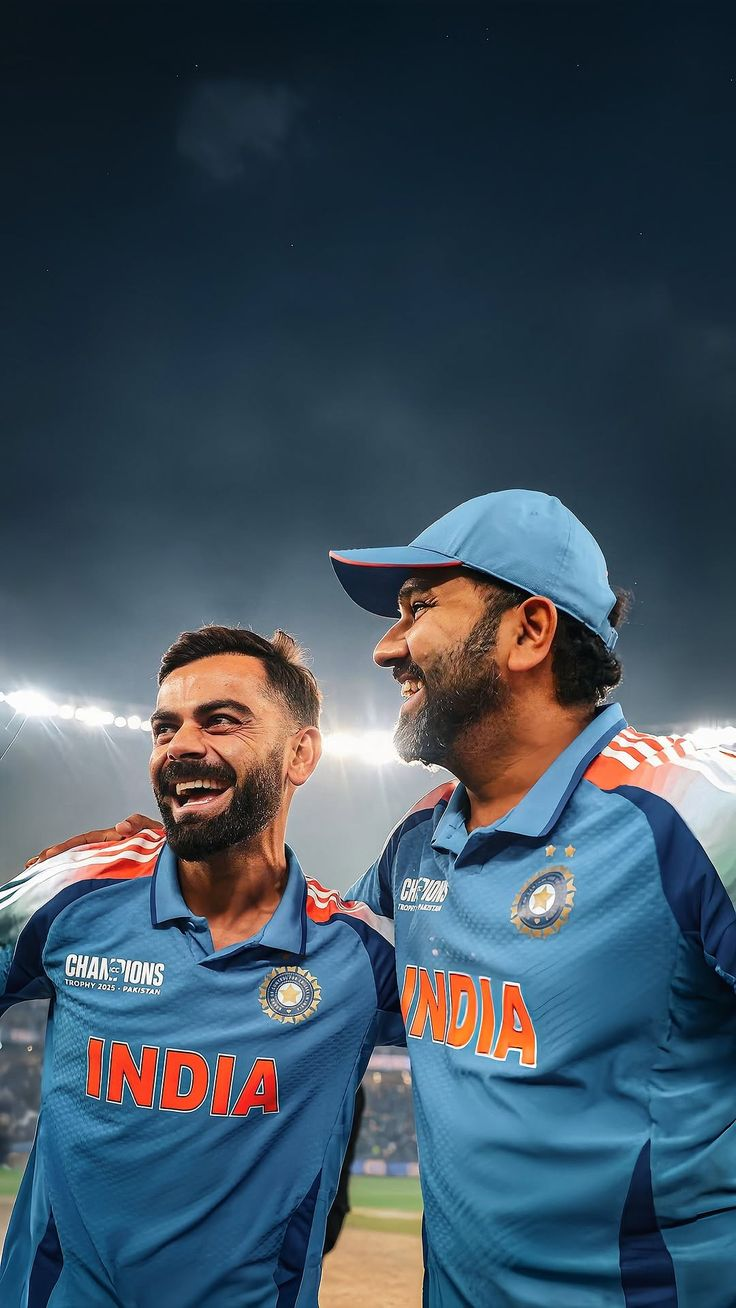

In [45]:
# Show the stego image inline
from pathlib import Path
from IPython.display import Image as IPImage, display, HTML
p = Path("stego_output.png")
if p.exists():
    display(IPImage(filename=str(p)))
else:
    display(HTML("<b>stego_output.png not found in current directory.</b>"))

In [46]:
# Stego detector: Chi-square pairs-of-values on LSBs + LSB entropy (Blue/Green/Red)
from scipy.stats import chi2 as chi2_dist

def _lsb_entropy(bits):
    n = bits.size
    if n == 0:
        return 0.0
    p1 = bits.sum() / float(n)
    p0 = 1.0 - p1
    # Avoid log(0)
    eps = 1e-12
    import math
    return float(-(p0*math.log2(p0+eps) + p1*math.log2(p1+eps)))


def stego_lsb_chi2_detect(img_path, channel='B', alpha=0.05):
    """
    Returns stats for one channel:
      - lsb_ratio, lsb_entropy
      - chi-square statistic on pairs-of-values (2k,2k+1) with p-value
    Heuristic:
      LSB replacement tends to equalize pairs (higher p-value) and push entropy toward 1.0.
      We mark encoded when p_value > 0.5 and lsb_entropy > 0.95.
    """
    try:
        pil_img = Image.open(img_path).convert('RGB')
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    except Exception as e:
        return {"error": f"Failed to load image: {e}", "verdict": "Unknown"}

    ch_index = {'B':0,'G':1,'R':2}[channel]
    ch = img[:,:,ch_index].astype(np.uint8)
    flat = ch.ravel()

    # LSB stats
    lsb = flat & 1
    ones = int(lsb.sum())
    zeros = int(lsb.size - ones)
    lsb_ratio = ones / float(ones + zeros) if (ones+zeros)>0 else 0.0
    lsb_ent = _lsb_entropy(lsb)

    # Chi-square on pairs (2k, 2k+1)
    hist = np.bincount(flat, minlength=256)
    chi2 = 0.0
    df = 0
    for k in range(0,256,2):
        h0 = hist[k]
        h1 = hist[k+1]
        s = h0 + h1
        if s == 0:
            continue
        exp = s/2.0
        chi2 += ((h0-exp)**2)/exp + ((h1-exp)**2)/exp
        df += 1
    df = max(df-1, 1)  # conservative
    p_value = float(chi2_dist.sf(chi2, df))

    # Revised heuristic
    encoded = (p_value > 0.5) and (lsb_ent > 0.95)

    return {
        "channel": channel,
        "lsb_ratio": lsb_ratio,
        "lsb_entropy": lsb_ent,
        "chi2": float(chi2),
        "df": int(df),
        "p_value": p_value,
        "encoded": bool(encoded)
    }


def check_image_stego(img_path, channels=("B","G","R"), alpha=0.05):
    results = [stego_lsb_chi2_detect(img_path, c, alpha) for c in channels]
    encoded_votes = sum(1 for r in results if r.get("encoded", False))
    encoded = encoded_votes >= 2  # majority of channels
    verdict = "Likely ENCODED" if encoded else "Likely CLEAN"
    return verdict, results

In [47]:
# Guided-blind detector: focus on predicted good pixels and apply monobit and runs tests
import math
def _monobit_p_value(bits):
    n = bits.size
    if n == 0: return 1.0
    s_obs = abs((bits*2-1).sum())
    s = s_obs / math.sqrt(n)
    # Approximate erfc-based p-value
    try:
        from math import erfc
        return float(erfc(s / math.sqrt(2)))
    except Exception:
        return float(np.exp(-2*(s**2)))
def _runs_p_value(bits):
    n = bits.size
    if n < 2: return 1.0
    pi = bits.mean()
    if abs(pi-0.5) > 0.25:
        return 0.0  # not applicable
    # Number of runs
    runs = 1 + int(np.sum(bits[1:] != bits[:-1]))
    num = abs(runs - 2*n*pi*(1-pi))
    den = 2*math.sqrt(2*n)*pi*(1-pi)
    from math import erfc
    return float(erfc(num/den)) if den>0 else 0.0
def detect_guided_with_model(img_path, model_path="lsb_pixel_classifier.pkl"):
    good_pixels, img = get_good_pixels(img_path, model_path)
    if img is None or len(good_pixels)==0:
        return {"error":"No image or good pixels found.", "verdict":"Unknown"}
    chB = img[:,:,0]
    xs, ys = zip(*good_pixels)
    xs = np.array(xs); ys = np.array(ys)
    b_vals = chB[xs, ys]
    bits = (b_vals & 1).astype(np.uint8)
    ent = _lsb_entropy(bits)
    p1 = _monobit_p_value(bits)
    p2 = _runs_p_value(bits)
    encoded = (ent > 0.95) and (min(p1,p2) > 0.5)
    return {
        "tested_bits": int(bits.size),
        "lsb_entropy": float(ent),
        "monobit_p": float(p1),
        "runs_p": float(p2),
        "encoded": bool(encoded)
    }

In [48]:
# Demo: Run detector on input and stego images
for p in ["input_img.jpeg", "stego_output.png"]:
    verdict, details = check_image_stego(p)
    print(f"\nImage: {p}")
    print("Verdict:", verdict)
    for r in details:
        if 'error' in r:
            print(f"  {r.get('channel', 'N/A')}: {r['error']}")
        else:
            print(f"  Channel {r['channel']}: LSB ratio={r['lsb_ratio']:.3f}, chi2={r['chi2']:.1f}, df={r['df']}, p={r['p_value']:.4g}, encoded={r['encoded']}")


Image: input_img.jpeg
Verdict: Likely CLEAN
  Channel B: LSB ratio=0.499, chi2=10354.0, df=127, p=0, encoded=False
  Channel G: LSB ratio=0.502, chi2=6749.4, df=127, p=0, encoded=False
  Channel R: LSB ratio=0.500, chi2=12371.2, df=127, p=0, encoded=False

Image: stego_output.png
Verdict: Likely CLEAN
  Channel B: LSB ratio=0.499, chi2=10332.1, df=127, p=0, encoded=False
  Channel G: LSB ratio=0.502, chi2=6749.4, df=127, p=0, encoded=False
  Channel R: LSB ratio=0.500, chi2=12371.2, df=127, p=0, encoded=False


In [49]:
# Demo: Guided-blind detector using the pixel classifier
for p in ["input_img.jpeg", "stego_output.png"]:
    res = detect_guided_with_model(p)
    print(f"\nGuided detector on {p}:")
    if 'error' in res:
        print(res['error'])
    else:
        print(f" tested_bits={res['tested_bits']}, entropy={res['lsb_entropy']:.3f}, monobit_p={res['monobit_p']:.3f}, runs_p={res['runs_p']:.3f}, encoded={res['encoded']}")

✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156550 good pixels for hiding.

Guided detector on input_img.jpeg:
 tested_bits=156550, entropy=1.000, monobit_p=0.000, runs_p=0.000, encoded=False
✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156556 good pixels for hiding.

Guided detector on stego_output.png:
 tested_bits=156556, entropy=1.000, monobit_p=0.000, runs_p=0.000, encoded=False


In [50]:
# Demo: Decode from stego_output.png using original good pixels
orig_img_path = "input_img.jpeg"
stego_path = "stego_output.png"
good_pixels_for_decode, orig_img = get_good_pixels(orig_img_path)
stego_img = cv2.imread(stego_path)
if stego_img is None:
    print("❌ Stego image not found; run the example usage cell first.")
else:
    # We know the embedded message length; decode exactly that many bytes
    msg = "Hello Chirag, your secret message is here!"
    decoded = decode_message(stego_img, good_pixels_for_decode, length_bytes=len(msg))
    print("🔓 Decoded:", decoded)

✅ Image loaded successfully using PIL/OpenCV. Shape: (1308, 736, 3)
✅ Found 156550 good pixels for hiding.
🔓 Decoded: Hello Chirag, your secret message is here!
